In [59]:
import pandas as pd

In [60]:
telecom_df = pd.read_csv(r"D:\CoWork\data\telecom_churn_processed.csv")

In [61]:
telecom_df.head()

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,0,False
1,2,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62,39,5973,False
2,3,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,148828,49,24,193,True
3,4,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,38722,80,25,9377,True
4,5,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,55098,78,15,1393,False


In [62]:
telecom_df = telecom_df.drop(['customer_id',"pincode"], axis=1)
telecom_df["date_of_registration"] = pd.to_datetime(telecom_df["date_of_registration"])

In [63]:
telecom_df.columns

Index(['telecom_partner', 'gender', 'age', 'state', 'city',
       'date_of_registration', 'num_dependents', 'estimated_salary',
       'calls_made', 'sms_sent', 'data_used', 'churn'],
      dtype='str')

In [64]:
telecom_df["churn"] = telecom_df["churn"].map({True:1,False:0})
telecom_df["gender"] = telecom_df["gender"].map({"M":1,"F":0})

In [65]:
telecom_df["telecom_partner"].value_counts()

telecom_partner
Reliance Jio    61123
Airtel          60905
Vodafone        60802
BSNL            60723
Name: count, dtype: int64

In [66]:
telecom_encoded_df = pd.get_dummies(telecom_df, columns=["telecom_partner"], dtype = int)
telecom_encoded_df['date_of_registration'] = (telecom_df["date_of_registration"].max() - telecom_df["date_of_registration"]).dt.days
telecom_encoded_df = telecom_encoded_df.rename(columns={'date_of_registration': 'tenure_days'})

In [67]:
telecom_encoded_df.head()

,gender,age,state,city,tenure_days,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn,telecom_partner_Airtel,telecom_partner_BSNL,telecom_partner_Reliance Jio,telecom_partner_Vodafone
0,0,25,Karnataka,Kolkata,1219,4,124962,44,45,0,0,0,0,1,0
1,0,55,Mizoram,Mumbai,1219,2,130556,62,39,5973,0,0,0,1,0
2,0,57,Arunachal Pradesh,Delhi,1219,0,148828,49,24,193,1,0,0,0,1
3,1,46,Tamil Nadu,Kolkata,1219,1,38722,80,25,9377,1,0,1,0,0
4,0,26,Tripura,Delhi,1219,2,55098,78,15,1393,0,0,1,0,0


In [68]:
telecom_df.head()

,telecom_partner,gender,age,state,city,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,Reliance Jio,0,25,Karnataka,Kolkata,2020-01-01,4,124962,44,45,0,0
1,Reliance Jio,0,55,Mizoram,Mumbai,2020-01-01,2,130556,62,39,5973,0
2,Vodafone,0,57,Arunachal Pradesh,Delhi,2020-01-01,0,148828,49,24,193,1
3,BSNL,1,46,Tamil Nadu,Kolkata,2020-01-01,1,38722,80,25,9377,1
4,BSNL,0,26,Tripura,Delhi,2020-01-01,2,55098,78,15,1393,0


In [69]:
telecom_df.dtypes

telecom_partner                    str
gender                           int64
age                              int64
state                              str
city                               str
date_of_registration    datetime64[us]
num_dependents                   int64
estimated_salary                 int64
calls_made                       int64
sms_sent                         int64
data_used                        int64
churn                            int64
dtype: object

In [70]:
telecom_df.nunique()

telecom_partner              4
gender                       2
age                         57
state                       28
city                         6
date_of_registration      1220
num_dependents               5
estimated_salary        110032
calls_made                 109
sms_sent                    54
data_used                10917
churn                        2
dtype: int64

In [71]:
telecom_df.describe()

,gender,age,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
count,243553.000000,243553.000000,243553,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000
mean,0.599364,46.077609,2021-09-01 00:00:00.354748,1.997500,85021.137839,49.120122,24.015754,5001.354802,0.200478
min,0.000000,18.000000,2020-01-01 00:00:00,0.000000,20000.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,32.000000,2020-10-31 00:00:00,1.000000,52585.000000,24.000000,11.000000,2490.000000,0.000000
50%,1.000000,46.000000,2021-09-01 00:00:00,2.000000,84990.000000,49.000000,24.000000,4987.000000,0.000000
75%,1.000000,60.000000,2022-07-03 00:00:00,3.000000,117488.000000,74.000000,36.000000,7493.000000,0.000000
max,1.000000,74.000000,2023-05-04 00:00:00,4.000000,149999.000000,108.000000,53.000000,10991.000000,1.000000
std,0.490028,16.444029,NaN,1.414941,37508.963233,29.260198,14.611419,2927.420055,0.400359


In [94]:

def cap_outliers_iqr(df, columns):
    """
    Caps outliers in specified columns using the IQR method.
    Values below Q1 - 1.5*IQR are set to the lower bound.
    Values above Q3 + 1.5*IQR are set to the upper bound.
    """
    df_capped = df.copy()
    
    for col in columns:
        Q1 = df_capped[col].quantile(0.25)
        Q3 = df_capped[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        n_outliers = ((df_capped[col] < lower_bound) | (df_capped[col] > upper_bound)).sum()
        print(f"{col}: capping {n_outliers} outliers (bounds: {lower_bound:.2f} to {upper_bound:.2f})")
        
        df_capped[col] = df_capped[col].clip(lower=lower_bound, upper=upper_bound)
    
    return df_capped




In [95]:
telecom_encoded_df.columns

Index(['gender', 'age', 'state', 'city', 'tenure_days', 'num_dependents',
       'estimated_salary', 'calls_made', 'sms_sent', 'data_used', 'churn',
       'telecom_partner_Airtel', 'telecom_partner_BSNL',
       'telecom_partner_Reliance Jio', 'telecom_partner_Vodafone'],
      dtype='str')

In [96]:
# Apply to all numeric columns you want capped
numeric_cols = ['age', 'num_dependents', 'estimated_salary', 
                 'calls_made', 'sms_sent', 'data_used', 'tenure_days']

telecom_encoded_df = cap_outliers_iqr(telecom_encoded_df, numeric_cols)

telecom_encoded_df.describe()

age: capping 0 outliers (bounds: -10.00 to 102.00)
num_dependents: capping 0 outliers (bounds: -2.00 to 6.00)
estimated_salary: capping 0 outliers (bounds: -44769.50 to 214842.50)
calls_made: capping 0 outliers (bounds: -51.00 to 149.00)
sms_sent: capping 0 outliers (bounds: -26.50 to 73.50)
data_used: capping 0 outliers (bounds: -5014.50 to 14997.50)
tenure_days: capping 0 outliers (bounds: -610.00 to 1830.00)


,gender,age,tenure_days,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn,telecom_partner_Airtel,telecom_partner_BSNL,telecom_partner_Reliance Jio,telecom_partner_Vodafone
count,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000
mean,0.599364,46.077609,609.999996,1.997500,85021.137839,49.120122,24.015754,5001.354802,0.200478,0.250069,0.249322,0.250964,0.249646
std,0.490028,16.444029,351.897027,1.414941,37508.963233,29.260198,14.611419,2927.420055,0.400359,0.433053,0.432621,0.433569,0.432809
min,0.000000,18.000000,0.000000,0.000000,20000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,32.000000,305.000000,1.000000,52585.000000,24.000000,11.000000,2490.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,46.000000,610.000000,2.000000,84990.000000,49.000000,24.000000,4987.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,60.000000,915.000000,3.000000,117488.000000,74.000000,36.000000,7493.000000,0.000000,1.000000,0.000000,1.000000,0.000000
max,1.000000,74.000000,1219.000000,4.000000,149999.000000,108.000000,53.000000,10991.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [97]:
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

scaler = StandardScaler()


In [98]:
cols_to_scale = ['age', 'tenure_days', 'num_dependents', 'calls_made', 'sms_sent', 'data_used','estimated_salary']


In [113]:
telecom_encoded_df[cols_to_scale] = scaler.fit_transform(telecom_encoded_df[cols_to_scale])

In [ ]:
# # pip install category_encoders --break-system-packages   (if not installed)
# from category_encoders import TargetEncoder

# te = TargetEncoder(cols=['state', 'city'])
# X_train[['state', 'city']] = te.fit_transform(X_train[['state', 'city']], y_train)
# X_test[['state', 'city']] = te.transform(X_test[['state', 'city']])

In [ ]:
# X_train.head()

,gender,age,state,city,tenure_days,num_dependents,estimated_salary,calls_made,sms_sent,data_used,telecom_partner_Airtel,telecom_partner_BSNL,telecom_partner_Reliance Jio,telecom_partner_Vodafone
20207,1,0.542127,0.200342,0.200567,1.444695,1.416626,0.590435,1.224937,1.501806,0.249514,1,0,0,0
143778,1,0.116572,0.200000,0.203260,-0.311812,-1.411741,1.380258,0.746697,1.091671,0.838157,0,1,0,0
64505,0,0.663714,0.197382,0.198115,0.816559,0.002442,-0.668812,-1.337064,-1.642557,1.298612,0,1,0,0
108386,0,-1.403268,0.204558,0.203260,0.191265,0.709534,0.166733,-1.234584,0.271403,1.677709,0,0,0,1
37177,1,0.663714,0.193056,0.203488,1.203104,-0.704649,1.087781,-1.473704,-1.437490,-0.305972,1,0,0,0


In [ ]:
# X_train.describe()

,gender,age,state,city,tenure_days,num_dependents,estimated_salary,calls_made,sms_sent,data_used,telecom_partner_Airtel,telecom_partner_BSNL,telecom_partner_Reliance Jio,telecom_partner_Vodafone
count,194842.000000,1.948420e+05,194842.000000,194842.000000,1.948420e+05,1.948420e+05,1.948420e+05,1.948420e+05,1.948420e+05,1.948420e+05,194842.000000,194842.000000,194842.000000,194842.000000
mean,0.598731,9.000213e-17,0.200480,0.200480,-5.251340e-18,-9.335715e-18,-1.625727e-16,4.449052e-17,2.217232e-17,-1.468916e-16,0.249664,0.249156,0.251111,0.250069
std,0.490156,1.000003e+00,0.003609,0.002566,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,0.432820,0.432525,0.433653,0.433054
min,0.000000,-1.707236e+00,0.192245,0.196375,-1.732934e+00,-1.411741e+00,-1.733287e+00,-1.678664e+00,-1.642557e+00,-1.710922e+00,0.000000,0.000000,0.000000,0.000000
25%,0.000000,-8.561259e-01,0.198036,0.198115,-8.660497e-01,-7.046493e-01,-8.650755e-01,-8.588236e-01,-8.906443e-01,-8.576968e-01,0.000000,0.000000,0.000000,0.000000
50%,1.000000,-5.015328e-03,0.200518,0.201044,8.347219e-04,2.442352e-03,-2.352623e-03,-4.823273e-03,-2.020058e-03,-3.787733e-03,0.000000,0.000000,0.000000,0.000000
75%,1.000000,8.460952e-01,0.202739,0.203260,8.648769e-01,7.095340e-01,8.661721e-01,8.491771e-01,8.866041e-01,8.508050e-01,0.000000,0.000000,1.000000,1.000000
max,1.000000,1.697206e+00,0.208428,0.203488,1.731761e+00,1.416626e+00,1.730420e+00,2.010618e+00,1.980295e+00,2.046209e+00,1.000000,1.000000,1.000000,1.000000


In [104]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


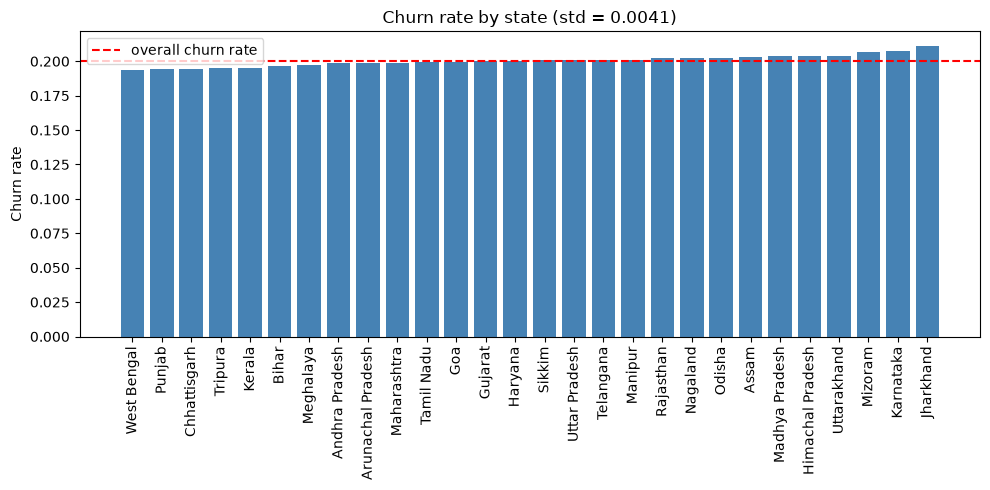

In [105]:

# Churn rate per state
state_churn = telecom_df.groupby('state')['churn'].mean().sort_values()

plt.figure(figsize=(10, 5))
plt.bar(state_churn.index, state_churn.values, color='steelblue')
plt.axhline(telecom_df['churn'].mean(), color='red', linestyle='--', label='overall churn rate')
plt.xticks(rotation=90)
plt.ylabel('Churn rate')
plt.title(f'Churn rate by state (std = {state_churn.std():.4f})')
plt.legend()
plt.tight_layout()
plt.show()

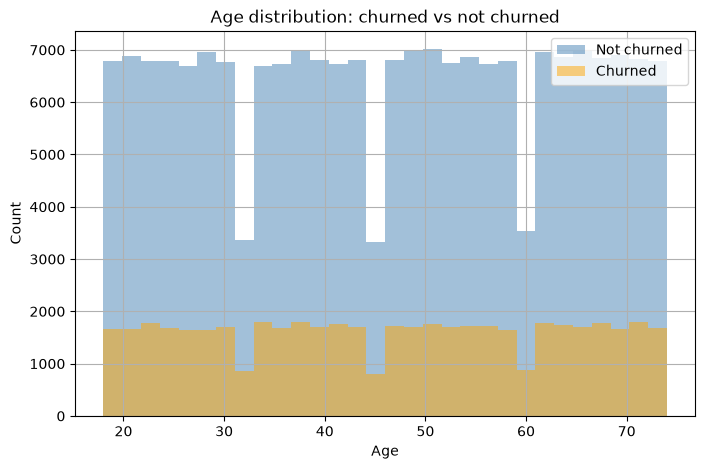

In [106]:
plt.figure(figsize=(8, 5))
telecom_df[telecom_df['churn'] == 0]['age'].hist(bins=30, alpha=0.5, label='Not churned', color='steelblue')
telecom_df[telecom_df['churn'] == 1]['age'].hist(bins=30, alpha=0.5, label='Churned', color='orange')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age distribution: churned vs not churned')
plt.legend()
plt.show()

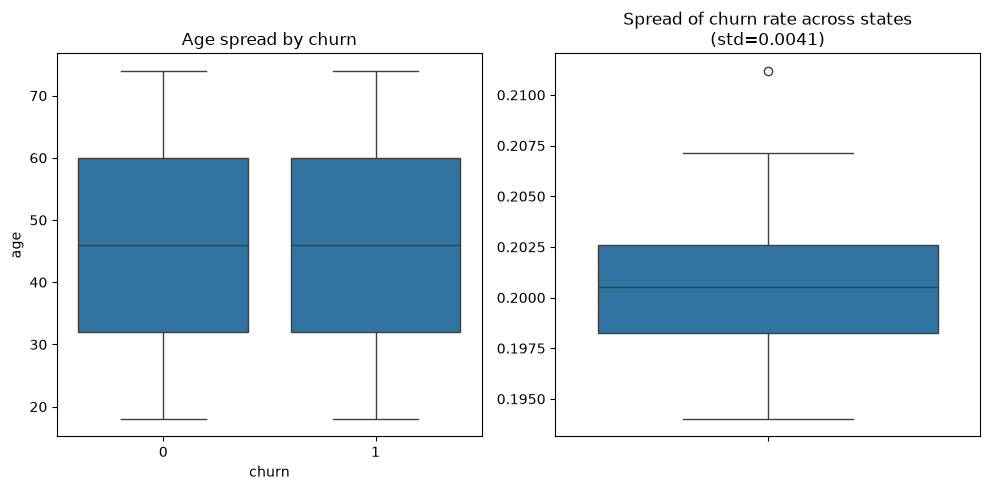

In [107]:

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

sns.boxplot(x='churn', y='age', data=telecom_df, ax=axes[0])
axes[0].set_title('Age spread by churn')

# Compare state churn rate spread visually
sns.boxplot(y=state_churn.values, ax=axes[1])
axes[1].set_title(f'Spread of churn rate across states\n(std={state_churn.std():.4f})')

plt.tight_layout()
plt.show()

In [109]:
telecom_encoded_df = telecom_encoded_df.drop(columns=['state', 'city'])


In [114]:
telecom_encoded_df.head()

,gender,age,tenure_days,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn,telecom_partner_Airtel,telecom_partner_BSNL,telecom_partner_Reliance Jio,telecom_partner_Vodafone
0,0,-1.281782,1.730623,1.415256,1.064837,-0.174986,1.436157,-1.708455,0,0,0,1,0
1,0,0.542593,1.730623,0.001767,1.213975,0.440185,1.025518,0.331912,0,0,0,1,0
2,0,0.664218,1.730623,-1.411722,1.701113,-0.004105,-0.001078,-1.642526,1,0,0,0,1
3,1,-0.004720,1.730623,-0.704977,-1.234351,1.055357,0.067362,1.494713,1,0,1,0,0
4,0,-1.220969,1.730623,0.001767,-0.797761,0.987004,-0.617036,-1.232608,0,0,1,0,0


In [126]:
telecom_encoded_df.describe()

,gender,age,tenure_days,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn,telecom_partner_Airtel,telecom_partner_BSNL,telecom_partner_Reliance Jio,telecom_partner_Vodafone
count,243553.000000,2.435530e+05,2.435530e+05,2.435530e+05,2.435530e+05,2.435530e+05,2.435530e+05,2.435530e+05,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000
mean,0.599364,-1.589402e-16,-1.194969e-16,7.316852e-17,1.578900e-16,-5.788131e-17,8.332109e-17,1.515884e-16,0.200478,0.250069,0.249322,0.250964,0.249646
std,0.490028,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,0.400359,0.433053,0.432621,0.433569,0.432809
min,0.000000,-1.707469e+00,-1.733465e+00,-1.411722e+00,-1.733486e+00,-1.678739e+00,-1.643633e+00,-1.708455e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,-8.560942e-01,-8.667326e-01,-7.049773e-01,-8.647588e-01,-8.585100e-01,-8.907951e-01,-8.578748e-01,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,-4.719619e-03,1.166788e-08,1.767202e-03,-8.301456e-04,-4.105302e-03,-1.078219e-03,-4.903577e-03,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,8.466550e-01,8.667326e-01,7.085117e-01,8.655779e-01,8.502994e-01,8.201989e-01,8.511421e-01,0.000000,1.000000,0.000000,1.000000,0.000000
max,1.000000,1.698030e+00,1.730623e+00,1.415256e+00,1.732332e+00,2.012290e+00,1.983675e+00,2.046053e+00,1.000000,1.000000,1.000000,1.000000,1.000000


In [118]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix


In [117]:
# pip install xgboost

In [121]:

# Split
X = telecom_encoded_df.drop(columns=['churn'])
y = telecom_encoded_df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [125]:
# --- Baseline: Logistic Regression ---
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced')
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)
print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, log_reg.predict_proba(X_test)[:, 1]))

Logistic Regression
              precision    recall  f1-score   support

           0       0.80      0.51      0.62     38946
           1       0.20      0.50      0.29      9765

    accuracy                           0.51     48711
   macro avg       0.50      0.50      0.46     48711
weighted avg       0.68      0.51      0.56     48711

ROC-AUC: 0.5049324745444932


In [123]:

# --- Random Forest ---
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("\nRandom Forest")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]))




Random Forest
              precision    recall  f1-score   support

           0       0.80      0.99      0.89     38946
           1       0.20      0.01      0.02      9765

    accuracy                           0.79     48711
   macro avg       0.50      0.50      0.45     48711
weighted avg       0.68      0.79      0.71     48711

ROC-AUC: 0.4964735409373395


In [124]:
# --- XGBoost (likely best performer) ---
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()  # handles class imbalance

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print("\nXGBoost")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1]))


XGBoost
              precision    recall  f1-score   support

           0       0.80      0.59      0.68     38946
           1       0.20      0.41      0.27      9765

    accuracy                           0.56     48711
   macro avg       0.50      0.50      0.48     48711
weighted avg       0.68      0.56      0.60     48711

ROC-AUC: 0.5019954487378365
